# Diagnostics: stats, robustness, cost sensitivity

This notebook consumes saved configs/panels and uses shared helpers to:
- Plot statistical estimates (Sharpe + CIs)
- Run/load robustness (seeds + shifted split)
- Run/load cost stress tests

Adjust seeds/steps/costs as needed; keep plots front and center.


In [17]:
import json
from pathlib import Path
import sys
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

NB   = Path.cwd()
ROOT = NB.parent
SRC  = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

from analysis.harness import run_robustness, run_cost_stress
from rl_agent.metrics import newey_west_sharpe_stats, block_bootstrap_ci

DATA = ROOT / "data" / "processed" / "cleaned" / "hedging_panel_spx.csv"
CFG = ROOT / "models" / "gae_run3" / "config.json"
ROBUST_CSV = ROOT / "reports" /'files'/ "robustness_summary.csv"
COST_CSV = ROOT / "reports" / 'files' / "cost_stress_summary.csv"


## Feature ablation (sensitivity)
Call the shared harness helper to test alternative feature sets and see validation Sharpe/maxDD.

In [18]:
from analysis.harness import run_feature_ablation
import json
from pathlib import Path

base_cfg = json.loads(CFG.read_text())
panel = pd.read_csv(DATA)

FEATURE_SETS = {
    "base": [f for f in base_cfg["features"] if f in panel.columns],
    "longer_tenor": [f for f in [g.replace("30d", "60d").replace("91d", "122d")
                                 for g in base_cfg["features"]] if f in panel.columns],
    "alt_skew": [f for f in [g.replace("25d", "40d") for g in base_cfg["features"]]
                 if f in panel.columns],
    "rv_120d": [f for f in [g.replace("rv_60d", "rv_120d") for g in base_cfg["features"]]
                if f in panel.columns],
}

steps = 1000  # fidelity vs. speed
ABLATE_CSV = ROOT / "reports" /'files' / "features_ablation.csv"
run_if_missing = False   # set False to just load existing CSV

if ABLATE_CSV.exists() and not run_if_missing:
    df_ablate = pd.read_csv(ABLATE_CSV)
else:
    df_ablate = run_feature_ablation(DATA, CFG, feature_sets=FEATURE_SETS, steps=steps)
    df_ablate.to_csv(ABLATE_CSV, index=False)

df_ablate


,Unnamed: 0,mean_bps,std_bps,sharpe,maxdd,steps,tag
0,0,2.271344,46.602912,0.773696,-0.060329,1954,base
1,1,2.832918,55.892338,0.804604,-0.129570,1954,longer_tenor
2,2,2.271344,46.602912,0.773696,-0.060329,1954,alt_skew
3,3,0.457981,36.998299,0.196502,-0.126406,1954,rv_120d


## Statistical estimates (NW + bootstrap)
Load trained policy + baselines, then plot Sharpe with CIs and regime attribution.

In [19]:
# Load trained policy + envs and define baselines
from rl_agent.deploy import load_policy
from rl_agent.experiment import deterministic_rewards
from simulator.baselines import hold_policy, vix_band_policy, vix_vol_target, volatility_targeting
from collections import OrderedDict
import numpy as np

panel = pd.read_csv(DATA, parse_dates=["date"])
policy_loaded, cfg_loaded, envs_loaded = load_policy(run_dir=CFG.parent, panel=panel, device="cpu")
env_tr, env_va, env_te = envs_loaded["env_tr"], envs_loaded["env_va"], envs_loaded["env_te"]

def _as_actor(fn):
    if hasattr(fn, "act"):
        return fn
    class _Tmp:
        def __init__(self, f):
            self.f=f
        def act(self, obs, deterministic=True):
            return float(self.f(obs)), None, None
    return _Tmp(fn)

# VIX mean/std in train to undo z-scoring for band/vol overlays
train_mask = panel["date"] <= pd.Timestamp(cfg_loaded["train_end"])
vix_mean = float(panel.loc[train_mask, "vix"].mean()) if "vix" in panel else 0.0
vix_std = float(panel.loc[train_mask, "vix"].std(ddof=1)) if "vix" in panel else 1.0

feat_idx = {name: i for i, name in enumerate(cfg_loaded.get("state_cols", cfg_loaded.get("features", [])))}
vix_idx = feat_idx.get("vix", 0)
long_spy = _as_actor(hold_policy(env_te.pos_limit))
gae_actor = _as_actor(policy_loaded)
policies = OrderedDict({
    "gae_policy": gae_actor,
    "long_spy": long_spy,
    "vix_band": _as_actor(vix_band_policy(vix_idx=vix_idx, low=20.0, high=30.0, pos_low=0.0, pos_high=env_te.pos_limit, vix_mean=vix_mean, vix_std=vix_std)),
    "vix_vol_target": _as_actor(vix_vol_target(vix_idx=vix_idx, vix_target=20.0, max_pos=env_te.pos_limit, vix_mean=vix_mean, vix_std=vix_std)),
    "vol_target": _as_actor(volatility_targeting(feature_idx=vix_idx, ann_vol_target=0.15)),
})

# Optionally include ML baseline if it was saved by 03_rl_training
ml_path = CFG.parent / "ml_model.pkl"
if ml_path.exists():
    blob = pickle.load(open(ml_path, "rb"))
    class _MLActor:
        def __init__(self, bundle, pos_limit):
            self.model = bundle["model"]
            self.mu = bundle["mu"]
            self.sg = bundle["sg"]
            self.scale = bundle["scale"]
            self.sign = bundle["sign"]
            self.pos_limit = float(pos_limit)
        def act(self, obs, deterministic=True):
            x = obs[-1] if obs.ndim > 1 else obs
            x_norm = (np.asarray(x, float) - self.mu) / self.sg
            pred = float(self.model.predict(x_norm.reshape(1, -1))[0])
            raw = self.sign * pred / self.scale
            import numpy as _np
            hedge = _np.clip(raw * self.pos_limit, -self.pos_limit, self.pos_limit)
            return float(hedge), None, None
    ml_actor = _MLActor(blob, pos_limit=env_te.pos_limit)
    policies["ml_gbr"] = ml_actor
    
splits = OrderedDict([("train", env_tr), ("valid", env_va), ("test", env_te)])
print(f"Loaded {len(policies)} policies; splits: {list(splits.keys())}")


Loaded 6 policies; splits: ['train', 'valid', 'test']


In [20]:
# Compute Newey--West SE and bootstrap CI per policy/split
import numpy as np

significance_rows = []
returns_cache = {}
if policies:
    for pname, pol in policies.items():
        for sname, env in splits.items():
            rewards = deterministic_rewards(env, pol)
            sharpe, se_sharpe, t_stat = newey_west_sharpe_stats(rewards)
            ci_lo, ci_hi = block_bootstrap_ci(rewards)
            significance_rows.append({
                "policy": pname,
                "split": sname,
                "steps": int(len(rewards)),
                "sharpe": sharpe,
                "se_sharpe": se_sharpe,
                "t_stat": t_stat,
                "ci_lo": ci_lo,
                "ci_hi": ci_hi,
            })
            idx = env.df["ret_fwd"].notna()
            dates = pd.to_datetime(env.df.loc[idx, "date"]).reset_index(drop=True) if "date" in env.df else pd.Series(range(len(rewards)))
            vix_series = env.df.loc[idx, "vix"].reset_index(drop=True) if "vix" in env.df else None
            offset = env.window
            start = offset
            end = start + len(rewards)
            aligned = pd.DataFrame({"date": dates.iloc[start:end].to_numpy()})
            if vix_series is not None and len(vix_series) >= end:
                aligned["vix"] = vix_series.iloc[start:end].to_numpy()
            aligned["reward_bps"] = rewards[: len(aligned)]
            returns_cache[(pname, sname)] = aligned

significance_df = pd.DataFrame(significance_rows)
significance_df.to_csv(ROOT / "reports" / "files" /  "stats_summary.csv")
if not significance_df.empty:
    display(significance_df.pivot(index="policy", columns="split", values="sharpe"))
    display(significance_df)
else:
    print("No data for significance; ensure model files exist.")


split,test,train,valid
policy,,,
gae_policy,0.561464,0.449215,0.733332
long_spy,0.223435,0.472675,0.447875
ml_gbr,0.166394,0.817551,0.857970
vix_band,0.164832,0.142306,0.380068
vix_vol_target,0.171959,0.331969,0.472255
vol_target,-0.026113,0.165276,0.341136


,policy,split,steps,sharpe,se_sharpe,t_stat,ci_lo,ci_hi
0,gae_policy,train,7008,0.449215,0.189224,2.373986,0.073715,0.776813
1,gae_policy,valid,1954,0.733332,0.356597,2.056470,0.058654,1.293159
2,gae_policy,test,7529,0.561464,0.182399,3.078225,0.286043,0.810089
3,long_spy,train,7008,0.472675,0.188922,2.501960,0.076046,0.909142
4,long_spy,valid,1954,0.447875,0.358305,1.249986,-0.225269,1.216980
5,long_spy,test,7529,0.223435,0.182842,1.222013,-0.116907,0.617985
6,vix_band,train,7008,0.142306,0.190056,0.748756,-0.225290,0.566981
7,vix_band,valid,1954,0.380068,0.358511,1.060129,-0.487632,0.832769
8,vix_band,test,7529,0.164832,0.182822,0.901598,-0.181956,0.568611
9,vix_vol_target,train,7008,0.331969,0.189397,1.752770,-0.046742,0.765795


## Regime attribution
Slice deterministic rewards by VIX terciles and named subperiods.

In [21]:
import numpy as np

regime_records = []
period_records = []
periods = [
    ("GFC_2008_2009", "2008-01-01", "2009-12-31"),
    ("Eurozone_2010_2012", "2010-01-01", "2012-12-31"),
    ("Calm_2017_2019", "2017-01-01", "2019-12-31"),
    ("COVID_2020_2021", "2020-01-01", "2021-12-31"),
    ("Post_2022_2023", "2022-01-01", "2023-12-31"),
]

if returns_cache:
    vix_series = None
    # Use test VIX to set terciles if available
    for (pname, sname), df in returns_cache.items():
        if sname == "test" and "vix" in df.columns:
            vix_series = df["vix"].dropna()
            break
    if vix_series is None:
        # fallback: take any vix column
        for df in returns_cache.values():
            if "vix" in df.columns:
                vix_series = df["vix"].dropna()
                break
    if vix_series is not None and not vix_series.empty:
        vix_cutoffs = vix_series.quantile([0.33, 0.66]).to_numpy()
        bins = [-np.inf, vix_cutoffs[0], vix_cutoffs[1], np.inf]
        labels = ["low", "mid", "high"]
    else:
        bins = None

    for (pname, sname), df in returns_cache.items():
        df = df.copy()
        if "date" in df.columns:
            df["date"] = pd.to_datetime(df["date"])
        # VIX tercile regimes
        if bins is not None and "vix" in df.columns:
            df["vix_regime"] = pd.cut(df["vix"], bins=bins, labels=labels)
            for regime, grp in df.groupby("vix_regime", observed=False):
                if grp.empty or len(grp) < 5:
                    continue
                mean_bps = grp["reward_bps"].mean()
                std_bps = grp["reward_bps"].std(ddof=1)
                if std_bps <= 0 or np.isnan(std_bps):
                    continue
                sharpe = mean_bps / std_bps * np.sqrt(252)
                regime_records.append({
                    "policy": pname,
                    "split": sname,
                    "regime": regime,
                    "mean_bps": mean_bps,
                    "std_bps": std_bps,
                    "sharpe": sharpe,
                })
        # Named periods
        if "date" in df.columns:
            for label, start, end in periods:
                mask = (df["date"] >= start) & (df["date"] <= end)
                grp = df.loc[mask]
                if grp.empty or len(grp) < 5:
                    continue
                mean_bps = grp["reward_bps"].mean()
                std_bps = grp["reward_bps"].std(ddof=1)
                if std_bps <= 0 or np.isnan(std_bps):
                    continue
                sharpe = mean_bps / std_bps * np.sqrt(252)
                period_records.append({
                    "policy": pname,
                    "split": sname,
                    "period": label,
                    "mean_bps": mean_bps,
                    "std_bps": std_bps,
                    "sharpe": sharpe,
                })

regime_df = pd.DataFrame(regime_records)
regime_df.to_csv(ROOT / 'reports' /'files'/ 'regime_summary.csv')
period_df = pd.DataFrame(period_records)
period_df.to_csv(ROOT / 'reports' /'files'/ 'period_summary.csv')
if not regime_df.empty:
    display(regime_df)
if not period_df.empty:
    display(period_df)


,policy,split,regime,mean_bps,std_bps,sharpe
0,gae_policy,train,low,2.224765,54.713823,0.645487
1,gae_policy,train,mid,2.753067,97.641187,0.447594
2,gae_policy,train,high,1.489249,141.016501,0.167648
3,gae_policy,valid,low,2.469181,52.819056,0.742100
4,gae_policy,valid,mid,4.177012,82.890995,0.799942
5,gae_policy,valid,high,-0.705815,3.933267,-2.848639
6,gae_policy,test,low,1.154505,33.339190,0.549719
7,gae_policy,test,mid,1.723685,45.433575,0.602256
8,gae_policy,test,high,3.553807,88.691863,0.636078
9,long_spy,train,low,1.452820,41.038207,0.561984


,policy,split,period,mean_bps,std_bps,sharpe
0,gae_policy,train,GFC_2008_2009,7.308206,141.721047,0.818609
1,gae_policy,train,Eurozone_2010_2012,1.135459,90.554628,0.199049
2,gae_policy,train,Calm_2017_2019,1.521910,29.548145,0.817634
3,gae_policy,valid,Calm_2017_2019,2.710855,58.682156,0.733332
4,gae_policy,test,COVID_2020_2021,3.008996,70.072158,0.681673
5,gae_policy,test,Post_2022_2023,1.152110,48.143138,0.379892
6,long_spy,train,GFC_2008_2009,-1.804083,98.693437,-0.290181
7,long_spy,train,Eurozone_2010_2012,2.738478,68.490618,0.634715
8,long_spy,train,Calm_2017_2019,2.272148,19.696488,1.831252
9,long_spy,valid,Calm_2017_2019,1.126680,39.934072,0.447875


## Robustness (seeds + shifted split)
Run/load the robustness sweep (seeds x shifts) and plot Sharpe bands.


,tag,split,sharpe_mean,sharpe_std,maxdd_mean
0,base,test,0.445966,0.101329,-0.187734
1,base,train,0.910792,0.242650,-0.145803
2,base,valid,0.921728,0.123140,-0.056403
3,shift_365d,test,0.277189,0.239780,-0.217619
4,shift_365d,train,0.991427,0.262800,-0.180677
5,shift_365d,valid,0.824496,0.065529,-0.116258


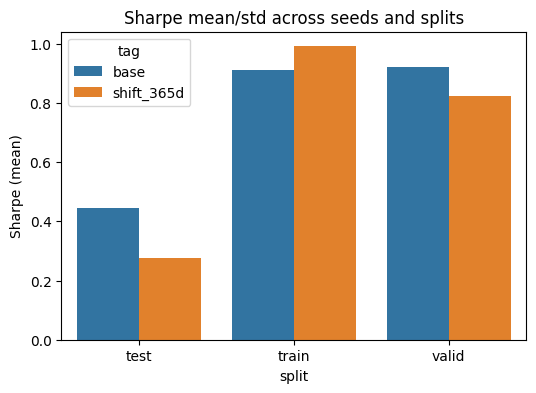

In [22]:
# Configure sweep
seeds = [12345, 23456, 34567, 45678, 56789, 67890, 78901]
shifts = [0, 365]
steps = max(500, int(json.loads(CFG.read_text()).get("steps", 10000)) // 4)

run_if_missing = False  # set True to re-run even if file exists
if ROBUST_CSV.exists() and not run_if_missing:
    robust_df = pd.read_csv(ROBUST_CSV)
else:
    robust_df = run_robustness(DATA, CFG, seeds=seeds, shifts=shifts, steps=steps)
    robust_df.to_csv(ROBUST_CSV, index=False)

if not robust_df.empty:
    bands = (
        robust_df.groupby(["tag", "split"])
        .agg(sharpe_mean=("sharpe", "mean"), sharpe_std=("sharpe", "std"), maxdd_mean=("maxdd", "mean"))
        .reset_index()
    )
    display(bands)
    plt.figure(figsize=(6,4))
    sns.barplot(data=bands, x="split", y="sharpe_mean", hue="tag", errorbar=("sd"), capsize=0.2)
    plt.ylabel("Sharpe (mean)")
    plt.title("Sharpe mean/std across seeds and splits")
    plt.show()
else:
    print("Robustness data not available; run the sweep above.")


## Cost sensitivity
Run/load a small cost stress test and plot Sharpe vs cost settings.


,mean_bps,std_bps,sharpe,maxdd,steps,split,txn_cost_bps,slippage_bps
0,2.227802,63.660512,0.555529,-0.248373,7008,train,10.0,8.0
1,2.271344,46.602912,0.773696,-0.060329,1954,valid,10.0,8.0
2,1.036870,46.577787,0.353383,-0.206937,7529,test,10.0,8.0
3,2.767578,64.648363,0.679583,-0.161326,7008,train,20.0,8.0
4,2.047105,47.501129,0.684127,-0.086742,1954,valid,20.0,8.0
5,1.460177,51.131790,0.453330,-0.211821,7529,test,20.0,8.0
6,2.419892,61.373048,0.625920,-0.194729,7008,train,10.0,16.0
7,2.082634,46.827642,0.706010,-0.131459,1954,valid,10.0,16.0
8,1.497071,49.794301,0.477269,-0.274988,7529,test,10.0,16.0


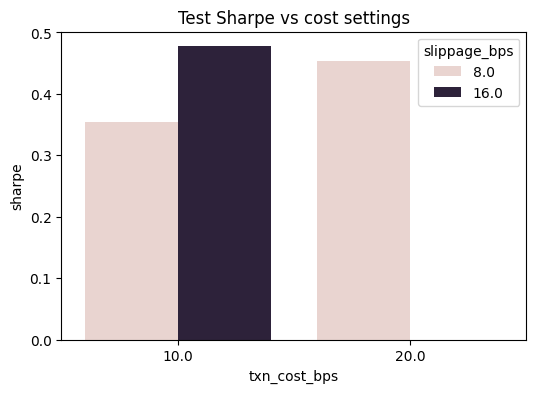

In [23]:
configs = [
    (float(json.loads(CFG.read_text())["txn_cost_bps"]), float(json.loads(CFG.read_text()).get("slippage_bps", 0.0))),
    (2*float(json.loads(CFG.read_text())["txn_cost_bps"]), float(json.loads(CFG.read_text()).get("slippage_bps", 0.0))),
    (float(json.loads(CFG.read_text())["txn_cost_bps"]), max(1.0, 2*float(json.loads(CFG.read_text()).get("slippage_bps", 0.0)))),
]
steps = 1000

run_if_missing = False  # set False to skip re-run if file exists
if COST_CSV.exists() and not run_if_missing:
    cost_df = pd.read_csv(COST_CSV)
else:
    cost_df = run_cost_stress(DATA, CFG, configs=configs, steps=steps)
    cost_df.to_csv(COST_CSV, index=False)

if not cost_df.empty:
    display(cost_df)
    plt.figure(figsize=(6,4))
    sns.barplot(data=cost_df[cost_df["split"]=="test"], x="txn_cost_bps", y="sharpe", hue="slippage_bps", errorbar=None)
    plt.title("Test Sharpe vs cost settings")
    plt.show()
else:
    print("Cost stress data not available; run the sweep above.")


## State-dependent slippage/impact
Example: widen costs when VIX is high and add a quadratic impact term on fast turnover.
Pass this to the cost stress runner via the new `slippage_fn` hook.


In [ ]:
from analysis.harness import stress_slippage

# Example: rerun cost stress with state-dependent slippage
SLIP_CSV = ROOT / 'reports' / 'files'/ 'cost_stress_slippage.csv'
run_if_missing = False

if SLIP_CSV.exists() and not run_if_missing:
    slip_cost_df = pd.read_csv(SLIP_CSV)
else:
    slip_cost_df = run_cost_stress(DATA, CFG, configs=configs, steps=steps, slippage_fn=stress_slippage)
    slip_cost_df.to_csv(SLIP_CSV, index=False)

slip_cost_df.head()

,mean_bps,std_bps,sharpe,maxdd,steps,split,txn_cost_bps,slippage_bps
0,1.746114,59.267368,0.467689,-0.396878,7008,train,10.0,8.0
1,2.851306,41.393998,1.093470,-0.047071,1954,valid,10.0,8.0
2,1.789592,44.915980,0.632490,-0.075837,7529,test,10.0,8.0
3,2.337364,64.678009,0.573680,-0.249592,7008,train,20.0,8.0
4,2.261928,47.472879,0.756369,-0.072224,1954,valid,20.0,8.0


## Extended walk-forward (2008–2009)
Run an additional split that puts 2008–2009 into test to check robustness across older stress regimes.


In [ ]:
# Define stress split and run a minimal sweep with custom config
stress_split = {"tag": "stress_2008", "train_end": "2006-12-31", "valid_end": "2007-12-31"}
seeds = [12345, 23456, 34567, 45678, 56789]
steps = max(500, int(json.loads(CFG.read_text()).get("steps", 10000)) // 4)
STRESS_CSV = ROOT / "reports" /"files"/ "stress_2008_summary.csv"

cfg_stress = json.loads(CFG.read_text())
cfg_stress.update(train_end=stress_split["train_end"], valid_end=stress_split["valid_end"])
CFG_STRESS = CFG.with_name("config_stress_2008.json")
CFG_STRESS.write_text(json.dumps(cfg_stress, indent=2))

# Run one split (shifts=[0]) using the stress config
run_if_missing = False  # set False to skip re-run if file exists
if STRESS_CSV.exists() and not run_if_missing:
    stress_df = pd.read_csv(STRESS_CSV)
else:
    stress_df = run_robustness(DATA, CFG_STRESS, seeds=seeds, shifts=[0, 90, 180], steps=steps)
    stress_df.to_csv(STRESS_CSV, index=False)
    stress_df["tag"] = stress_split["tag"]


display(stress_df)


,mean_bps,std_bps,sharpe,maxdd,steps,tag,seed,split
0,2.318100,53.066244,0.693448,-0.081540,415,stress_2008,12345,train
1,10.825472,116.379223,1.476630,-0.057339,214,stress_2008,12345,valid
2,-1.496580,45.986529,-0.516618,-0.927655,15862,stress_2008,12345,test
3,2.305776,54.591015,0.670496,-0.076588,415,stress_2008,23456,train
4,8.274720,120.532620,1.089805,-0.044563,214,stress_2008,23456,valid
5,-0.628372,50.419732,-0.197841,-0.817715,15862,stress_2008,23456,test
6,3.309087,61.466380,0.854616,-0.082559,415,stress_2008,34567,train
7,7.319408,132.396735,0.877605,-0.097875,214,stress_2008,34567,valid
8,-1.293440,50.042768,-0.410303,-0.923432,15862,stress_2008,34567,test
9,4.893112,82.306703,0.943735,-0.114130,415,stress_2008,45678,train
